## Import Libraries

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Dataset Load

In [6]:
df = pd.read_csv(r"Kaggle_Ecommerce Data.csv")

In [332]:
df

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23/12/2023,27/12/2023,West,No,NaN,NaN,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,3/4/2025,9/4/2025,South,No,NaN,NaN,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,8/10/2024,12/10/2024,North,No,NaN,NaN,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14/9/2024,20/9/2024,South,No,NaN,NaN,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21/12/2024,27/12/2024,East,No,NaN,NaN,13.88,2.74,1.15,39,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,13/8/2025,16/8/2025,North,No,NaN,NaN,8.35,3.04,-0.12,23,Female
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,4/12/2023,10/12/2023,South,Yes,27/12/2023,No longer needed,21.56,3.37,6.33,61,Female
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,1/2/2025,7/2/2025,East,No,NaN,NaN,1618.20,12.18,182.00,41,Female
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,27/3/2024,2/4/2024,East,No,NaN,NaN,21.94,5.61,0.53,27,Female


## First Look at Data

In [333]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23/12/2023,27/12/2023,West,No,NaN,NaN,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,3/4/2025,9/4/2025,South,No,NaN,NaN,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,8/10/2024,12/10/2024,North,No,NaN,NaN,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14/9/2024,20/9/2024,South,No,NaN,NaN,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21/12/2024,27/12/2024,East,No,NaN,NaN,13.88,2.74,1.15,39,Male


## Shape

In [334]:
df.shape

(34500, 19)

## Column Names

In [335]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivered_date', 'region', 'returned', 'request_date', 'return_reason',
       'total_amount', 'shipping_cost', 'profit_margin', 'customer_age',
       'customer_gender'],
      dtype='object')

## Dataset Information

In [336]:
df.info

<bound method DataFrame.info of       order_id customer_id product_id     category   price  discount  \
0      O100000      C17270    P234890         Home  164.08      0.15   
1      O100001      C17603    P228204      Grocery   24.73      0.00   
2      O100002      C10860    P213892  Electronics  175.58      0.05   
3      O100003      C15390    P208689  Electronics   63.67      0.00   
4      O100004      C15226    P228063         Home   16.33      0.15   
...        ...         ...        ...          ...     ...       ...   
34495  O134495      C13553    P231412      Fashion   10.44      0.20   
34496  O134496      C11349    P218266       Beauty    4.79      0.10   
34497  O134497      C12986    P204345  Electronics  323.64      0.00   
34498  O134498      C17196    P217644         Home   23.09      0.05   
34499  O134499      C13330    P207047         Home   76.84      0.00   

       quantity payment_method  order_date delivered_date region returned  \
0             1    Credit 

## Statistical Summary

In [337]:
df.describe()

,price,discount,quantity,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,12931.800000,15.650000,1536.170000,69.000000


## Missing Values

In [338]:
df.isnull().sum()

order_id               0
customer_id            0
product_id             0
category               0
price                  0
discount               0
quantity               0
payment_method         0
order_date             0
delivered_date         0
region                 0
returned               0
request_date       32597
return_reason      32597
total_amount           0
shipping_cost          0
profit_margin          0
customer_age           0
customer_gender        0
dtype: int64

## Duplicate Records

In [339]:
df.duplicated().sum()

0

## Missing Value Percentage

In [340]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(missing_percent, 2)
})

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
request_date,32597,94.48
return_reason,32597,94.48


## Handle Missing Values

In [341]:
df["return_reason"] = df["return_reason"].fillna("Not Returned")

In [342]:
df["return_reason"]

0            Not Returned
1            Not Returned
2            Not Returned
3            Not Returned
4            Not Returned
               ...       
34495        Not Returned
34496    No longer needed
34497        Not Returned
34498        Not Returned
34499        Not Returned
Name: return_reason, Length: 34500, dtype: object

In [343]:
df["returned"].value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [344]:
df["return_reason"].isnull().sum()

0

In [7]:
df["request_date"] = pd.to_datetime(df["request_date"])

C:\Users\Shivam shrivastav\AppData\Local\Temp\ipykernel_22944\2671904722.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["request_date"] = pd.to_datetime(df["request_date"])


In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["delivered_date"] = pd.to_datetime(df["delivered_date"])
df["request_date"] = pd.to_datetime(df["request_date"])

C:\Users\Shivam shrivastav\AppData\Local\Temp\ipykernel_22944\3788944117.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(df["order_date"])
C:\Users\Shivam shrivastav\AppData\Local\Temp\ipykernel_22944\3788944117.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["delivered_date"] = pd.to_datetime(df["delivered_date"])


In [347]:
df["order_date"]

0       2023-12-23
1       2025-04-03
2       2024-10-08
3       2024-09-14
4       2024-12-21
           ...    
34495   2025-08-13
34496   2023-12-04
34497   2025-02-01
34498   2024-03-27
34499   2025-09-11
Name: order_date, Length: 34500, dtype: datetime64[ns]

## Feature Engineering

In [9]:
df["delivery_days"] = (df["delivered_date"] - df["order_date"]).dt.days

In [10]:
df["delivery_days"]

0        4
1        6
2        4
3        6
4        6
        ..
34495    3
34496    6
34497    6
34498    6
34499    6
Name: delivery_days, Length: 34500, dtype: int64

In [350]:
df[["order_date","delivered_date","delivery_days"]].head()

,order_date,delivered_date,delivery_days
0,2023-12-23,2023-12-27,4
1,2025-04-03,2025-04-09,6
2,2024-10-08,2024-10-12,4
3,2024-09-14,2024-09-20,6
4,2024-12-21,2024-12-27,6


In [351]:
df["return_request_days"] = (
    df["request_date"] - df["delivered_date"]
).dt.days

In [352]:
df["return_request_days"]

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
34495     NaN
34496    17.0
34497     NaN
34498     NaN
34499     NaN
Name: return_request_days, Length: 34500, dtype: float64

In [353]:
df[["delivered_date","request_date","return_request_days"]].head()

,delivered_date,request_date,return_request_days
0,2023-12-27,NaT,NaN
1,2025-04-09,NaT,NaN
2,2024-10-12,NaT,NaN
3,2024-09-20,NaT,NaN
4,2024-12-27,NaT,NaN


In [354]:
df["order_month"] = df["order_date"].dt.month_name()

In [355]:
df["order_month"]

0         December
1            April
2          October
3        September
4         December
           ...    
34495       August
34496     December
34497     February
34498        March
34499    September
Name: order_month, Length: 34500, dtype: object

In [356]:
df["order_year"] = df["order_date"].dt.year

In [357]:
df["order_year"]

0        2023
1        2025
2        2024
3        2024
4        2024
         ... 
34495    2025
34496    2023
34497    2025
34498    2024
34499    2025
Name: order_year, Length: 34500, dtype: int32

In [358]:
df["order_day"] = df["order_date"].dt.day_name()

In [359]:
df["order_day"]

0         Saturday
1         Thursday
2          Tuesday
3         Saturday
4         Saturday
           ...    
34495    Wednesday
34496       Monday
34497     Saturday
34498    Wednesday
34499     Thursday
Name: order_day, Length: 34500, dtype: object

In [360]:
df["weekend_order"] = np.where(df["order_day"].isin(["Saturday", "Sunday"]),"Yes","No")

In [361]:
df["weekend_order"]

0        Yes
1         No
2         No
3        Yes
4        Yes
        ... 
34495     No
34496     No
34497    Yes
34498     No
34499     No
Name: weekend_order, Length: 34500, dtype: object

In [362]:
df["high_discount"] = np.where(df["discount"] >= 30,"Yes","No")

In [363]:
df["high_discount"]

0        No
1        No
2        No
3        No
4        No
         ..
34495    No
34496    No
34497    No
34498    No
34499    No
Name: high_discount, Length: 34500, dtype: object

In [364]:
df["large_order"] = np.where(df["quantity"] >= 3,"Yes","No")

In [365]:
df["large_order"] 

0         No
1         No
2         No
3         No
4         No
        ... 
34495     No
34496    Yes
34497    Yes
34498     No
34499     No
Name: large_order, Length: 34500, dtype: object

## Verify New Features

In [366]:
new_features = [
    "delivery_days",
    "return_request_days",
    "order_month",
    "order_year",
    "order_day",
    "weekend_order",
    "high_discount",
    "large_order"
]

df[new_features].head()

,delivery_days,return_request_days,order_month,order_year,order_day,weekend_order,high_discount,large_order
0,4,NaN,December,2023,Saturday,Yes,No,No
1,6,NaN,April,2025,Thursday,No,No,No
2,4,NaN,October,2024,Tuesday,No,No,No
3,6,NaN,September,2024,Saturday,Yes,No,No
4,6,NaN,December,2024,Saturday,Yes,No,No


## Age Group 

In [367]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["Teen", "18-25", "26-35", "36-45", "46-60", "60+"]
)

In [368]:
df[["customer_age", "age_group"]].head()

,customer_age,age_group
0,60,46-60
1,37,36-45
2,34,26-35
3,21,18-25
4,39,36-45


# Discount Bucket

In [369]:
df["discount_bucket"] = pd.cut(
    df["discount"],
    bins=[0, 10, 20, 30, 50],
    labels=["0-10%", "11-20%", "21-30%", "31-50%"]
)

In [370]:
df["discount_bucket"].value_counts()

discount_bucket
0-10%     15561
11-20%        0
21-30%        0
31-50%        0
Name: count, dtype: int64

## Profit Category

In [371]:
df["profit_category"] = pd.cut(
    df["profit_margin"],
    bins=[0, 10, 20, 30, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

In [372]:
df["profit_category"]

0        Very High
1              NaN
2           Medium
3              Low
4              Low
           ...    
34495          NaN
34496          Low
34497          NaN
34498          Low
34499       Medium
Name: profit_category, Length: 34500, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

## Shipping Cost Category

In [373]:
df["shipping_category"] = pd.qcut(
    df["shipping_cost"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [374]:
df["shipping_category"]

0          High
1           Low
2        Medium
3        Medium
4           Low
          ...  
34495       Low
34496       Low
34497      High
34498    Medium
34499      High
Name: shipping_category, Length: 34500, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

## Verify New Features

In [375]:
new_features = [
    "age_group",
    "discount_bucket",
    "profit_category",
    "shipping_category"
]

df[new_features].head()

,age_group,discount_bucket,profit_category,shipping_category
0,46-60,0-10%,Very High,High
1,36-45,NaN,NaN,Low
2,26-35,0-10%,Medium,Medium
3,18-25,NaN,Low,Medium
4,36-45,0-10%,Low,Low


## Exploratory Data Analysis (EDA)

In [11]:
return_count = df["returned"].value_counts()

print(return_count)

returned
No     32597
Yes     1903
Name: count, dtype: int64


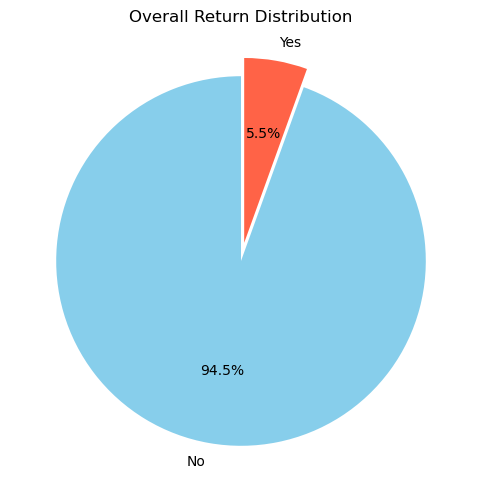

In [12]:
plt.figure(figsize=(6,6))

plt.pie(
    return_count,
    labels=return_count.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.1],
    colors=["skyblue","tomato"]
)

plt.title("Overall Return Distribution")

plt.show()

In [378]:
category_return = pd.crosstab(
    df["category"],
    df["returned"]
)

category_return

returned,No,Yes
category,,
Beauty,3948,155
Electronics,5729,451
Fashion,5736,518
Grocery,4005,53
Home,5177,310
Sports,3965,206
Toys,4037,210


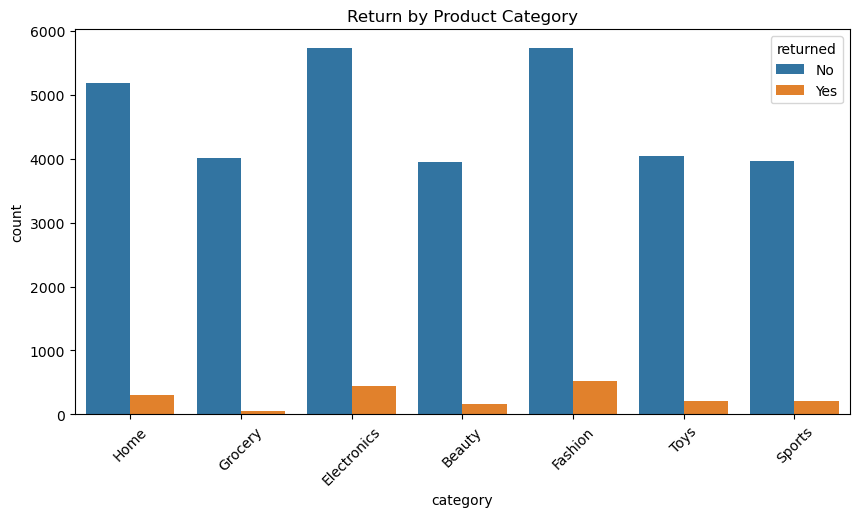

In [379]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="category",
    hue="returned"
)

plt.xticks(rotation=45)
plt.title("Return by Product Category")

plt.show()

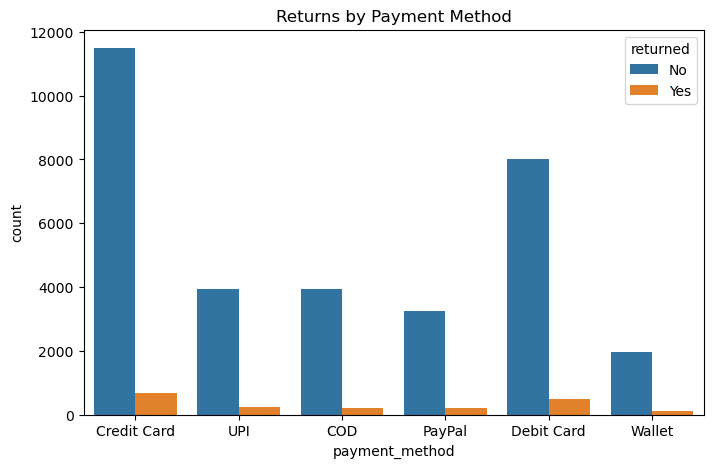

In [380]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="payment_method",
    hue="returned"
)

plt.title("Returns by Payment Method")

plt.show()

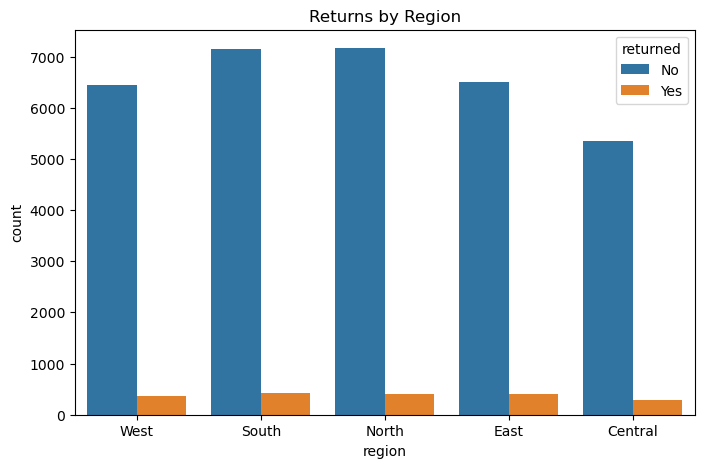

In [381]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="region",
    hue="returned"
)

plt.title("Returns by Region")

plt.show()

In [382]:
category_return_rate = (
    pd.crosstab(df["category"], df["returned"], normalize="index") * 100
).round(2)

category_return_rate

returned,No,Yes
category,,
Beauty,96.22,3.78
Electronics,92.70,7.30
Fashion,91.72,8.28
Grocery,98.69,1.31
Home,94.35,5.65
Sports,95.06,4.94
Toys,95.06,4.94


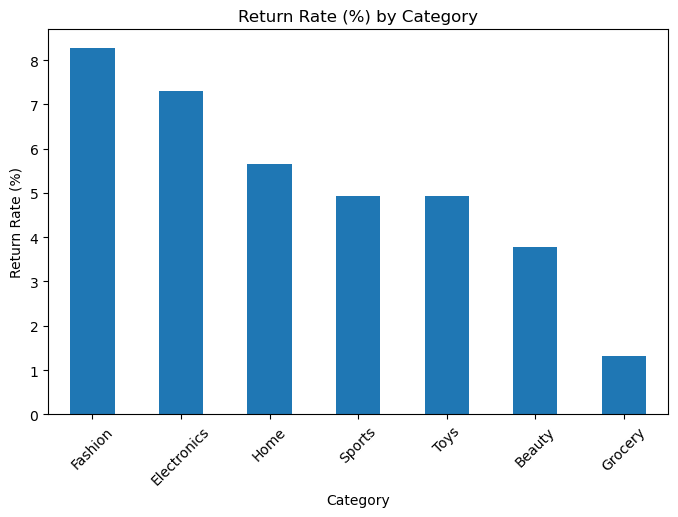

In [383]:
category_return_rate["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Return Rate (%) by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [384]:
payment_return_rate = (
    pd.crosstab(df["payment_method"], df["returned"], normalize="index") * 100
).round(2)

payment_return_rate

returned,No,Yes
payment_method,,
COD,94.90,5.10
Credit Card,94.45,5.55
Debit Card,94.33,5.67
PayPal,94.22,5.78
UPI,94.61,5.39
Wallet,94.62,5.38


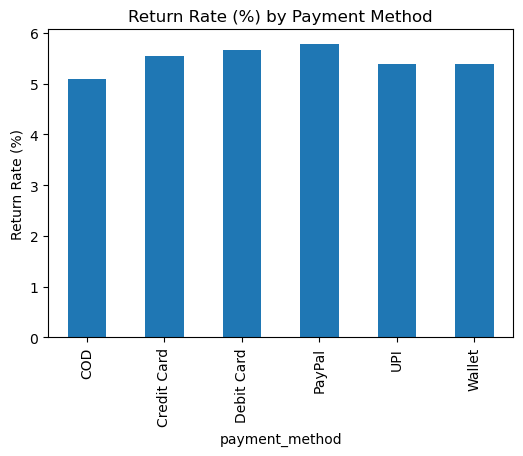

In [385]:
payment_return_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Return Rate (%) by Payment Method")
plt.ylabel("Return Rate (%)")
plt.show()

In [386]:
region_return_rate = (
    pd.crosstab(df["region"], df["returned"], normalize="index") * 100
).round(2)

region_return_rate

returned,No,Yes
region,,
Central,94.90,5.10
East,94.09,5.91
North,94.64,5.36
South,94.32,5.68
West,94.55,5.45


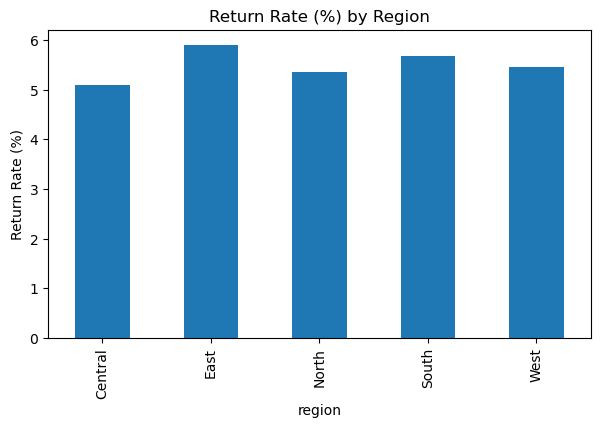

In [387]:
region_return_rate["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Return Rate (%) by Region")
plt.ylabel("Return Rate (%)")
plt.show()

In [388]:
gender_return_rate = (
    pd.crosstab(df["customer_gender"], df["returned"], normalize="index") * 100
).round(2)

gender_return_rate

returned,No,Yes
customer_gender,,
Female,94.38,5.62
Male,94.56,5.44
Other,94.83,5.17


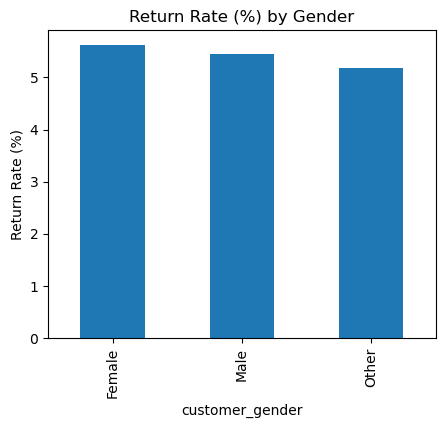

In [389]:
gender_return_rate["Yes"].plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Return Rate (%) by Gender")
plt.ylabel("Return Rate (%)")
plt.show()

In [390]:
discount_return = (
    pd.crosstab(df["discount_bucket"], df["returned"], normalize="index") * 100
).round(2)

discount_return

returned,No,Yes
discount_bucket,,
0-10%,94.36,5.64


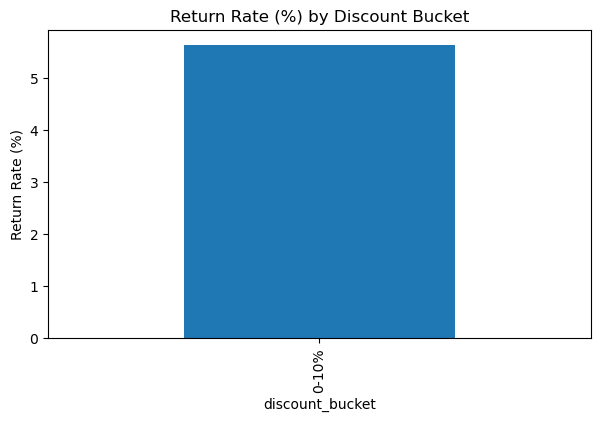

In [391]:
discount_return["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Return Rate (%) by Discount Bucket")
plt.ylabel("Return Rate (%)")
plt.show()

In [392]:
df.groupby("returned")[[
    "price",
    "discount",
    "quantity",
    "shipping_cost",
    "profit_margin",
    "customer_age",
    "delivery_days"
]].mean().round(2)

,price,discount,quantity,shipping_cost,profit_margin,customer_age,delivery_days
returned,,,,,,,
No,117.89,0.05,1.49,6.12,27.86,43.48,4.81
Yes,145.12,0.05,1.49,6.63,32.48,43.42,4.84


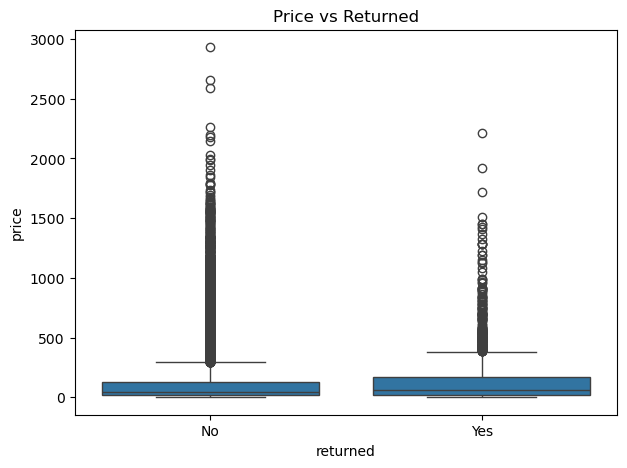

In [393]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="returned",
    y="price"
)

plt.title("Price vs Returned")
plt.show()

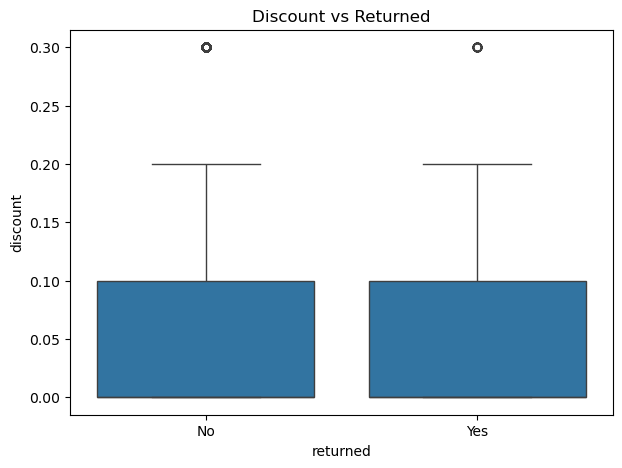

In [394]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="returned",
    y="discount"
)

plt.title("Discount vs Returned")
plt.show()

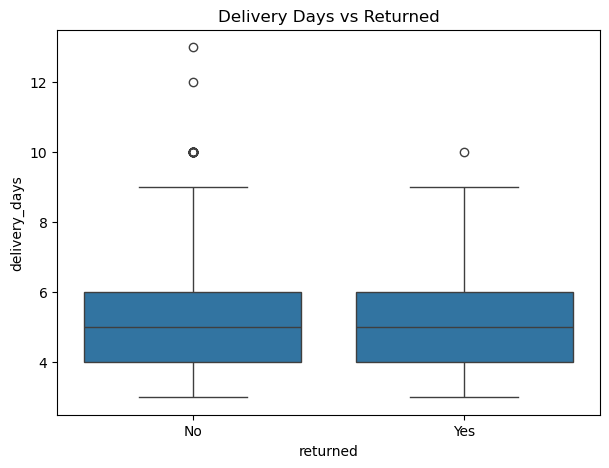

In [395]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="returned",
    y="delivery_days"
)

plt.title("Delivery Days vs Returned")
plt.show()

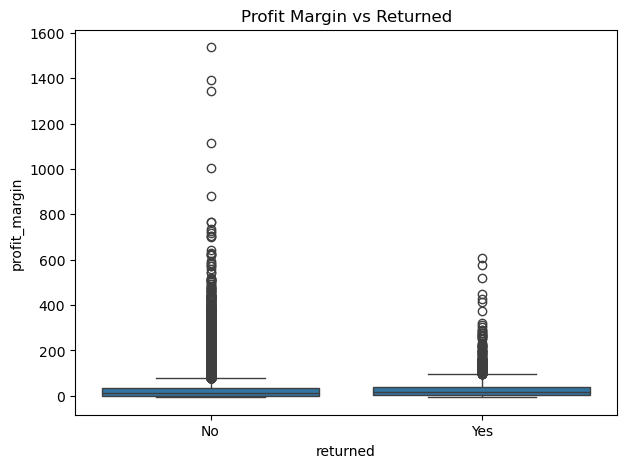

In [396]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="returned",
    y="profit_margin"
)

plt.title("Profit Margin vs Returned")
plt.show()

In [397]:
num_cols = df.select_dtypes(include=np.number)

num_cols.corr()

,price,discount,quantity,total_amount,shipping_cost,profit_margin,customer_age,delivery_days,return_request_days,order_year
price,1.000000,0.008736,0.005324,0.801426,0.654110,0.679105,-0.010550,0.007612,0.001612,-0.004669
discount,0.008736,1.000000,-0.008431,-0.031202,-0.046383,-0.047470,0.000181,0.002490,-0.003709,0.002619
quantity,0.005324,-0.008431,1.000000,0.304134,0.278292,0.388398,0.000352,0.005120,-0.001695,0.004276
total_amount,0.801426,-0.031202,0.304134,1.000000,0.599079,0.893327,-0.009870,0.005495,0.015769,-0.007126
shipping_cost,0.654110,-0.046383,0.278292,0.599079,1.000000,0.616730,-0.008951,0.007651,-0.012929,0.001374
profit_margin,0.679105,-0.047470,0.388398,0.893327,0.616730,1.000000,-0.007712,0.005832,0.012234,-0.004942
customer_age,-0.010550,0.000181,0.000352,-0.009870,-0.008951,-0.007712,1.000000,0.003624,0.003527,-0.005431
delivery_days,0.007612,0.002490,0.005120,0.005495,0.007651,0.005832,0.003624,1.000000,-0.002539,-0.006033
return_request_days,0.001612,-0.003709,-0.001695,0.015769,-0.012929,0.012234,0.003527,-0.002539,1.000000,0.042060
order_year,-0.004669,0.002619,0.004276,-0.007126,0.001374,-0.004942,-0.005431,-0.006033,0.042060,1.000000


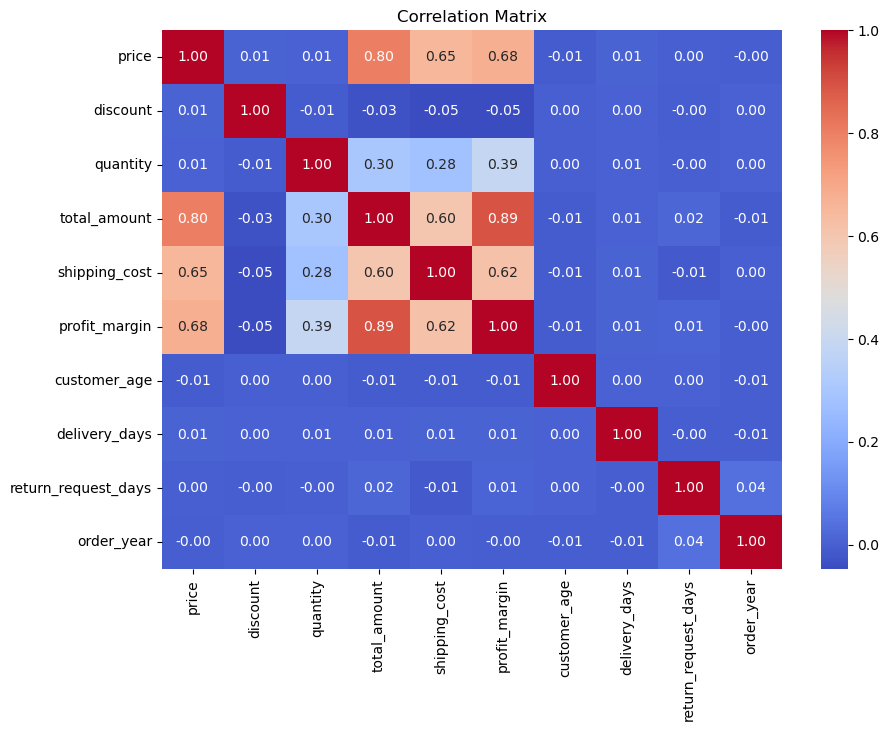

In [398]:
plt.figure(figsize=(10,7))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
df["return_reason"].value_counts()

return_reason
Not as described      490
No longer needed      481
Defective             465
Missing/Wrong item    439
Slow delivery          28
Name: count, dtype: int64

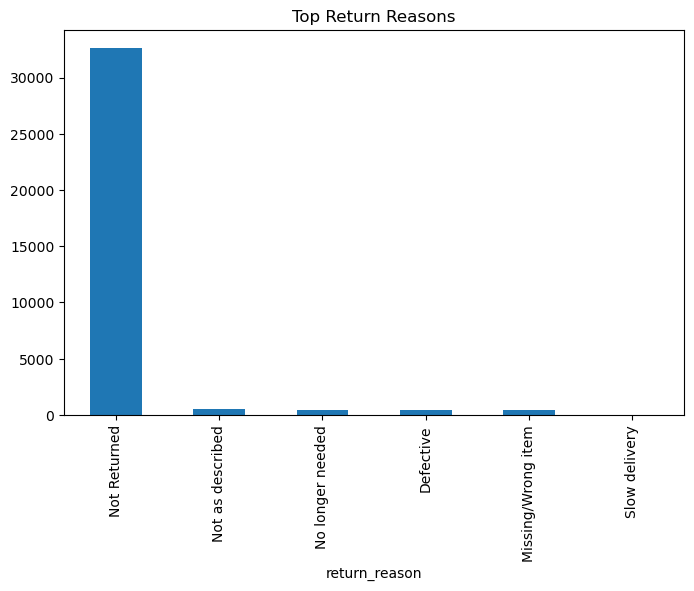

In [400]:
plt.figure(figsize=(8,5))

df["return_reason"].value_counts().plot(
    kind="bar"
)

plt.title("Top Return Reasons")

plt.show()

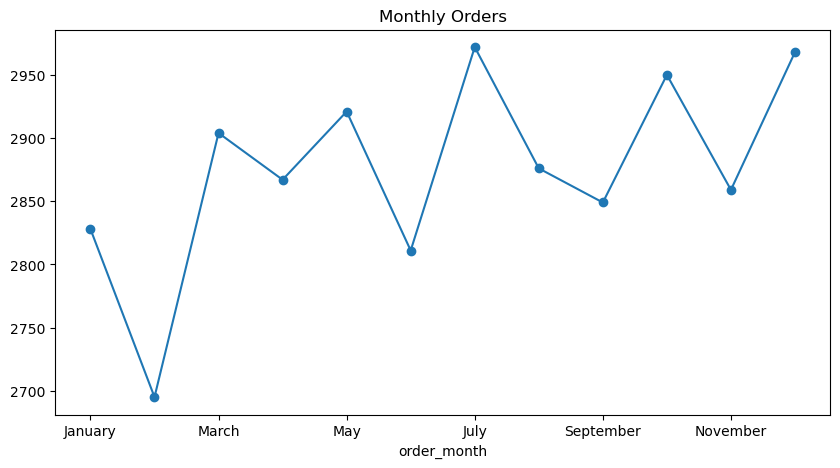

In [401]:
monthly_orders = (
    df.groupby("order_month")
      .size()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

monthly_orders.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Orders")

plt.show()

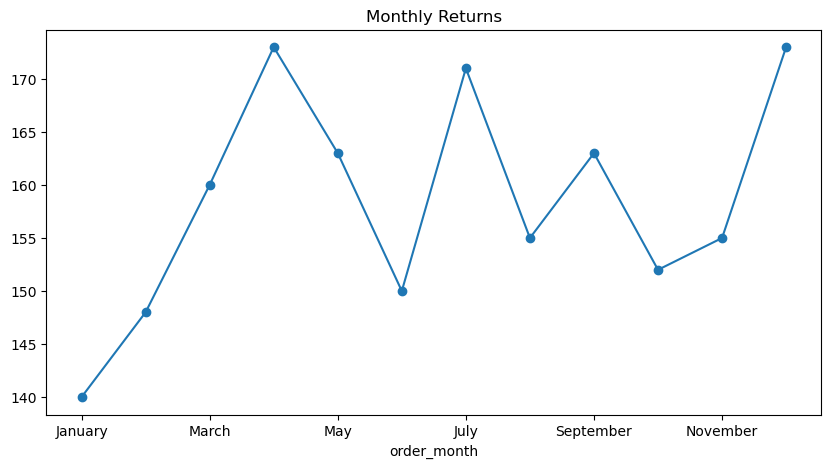

In [402]:
monthly_return = pd.crosstab(
    df["order_month"],
    df["returned"]
)

monthly_return = monthly_return.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

monthly_return["Yes"].plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Returns")

plt.show()

In [14]:
df["returned"] = df["returned"].map({"No": 0, "Yes": 1})

In [15]:
df["returned"]

0        0
1        0
2        0
3        0
4        0
        ..
34495    0
34496    1
34497    0
34498    0
34499    0
Name: returned, Length: 34500, dtype: int64

In [16]:
print(df["returned"].dtype)
print(df["returned"].value_counts(dropna=False))

int64
returned
0    32597
1     1903
Name: count, dtype: int64


## Drop Unnecessary Columns

In [17]:
df.drop(
    columns=[
        "order_id",
        "customer_id",
        "product_id",
        "order_date",
        "delivered_date",
        "request_date",
        "return_reason"
    ],
    inplace=True
)

In [407]:
df.columns

Index(['category', 'price', 'discount', 'quantity', 'payment_method', 'region',
       'returned', 'total_amount', 'shipping_cost', 'profit_margin',
       'customer_age', 'customer_gender', 'delivery_days',
       'return_request_days', 'order_month', 'order_year', 'order_day',
       'weekend_order', 'high_discount', 'large_order', 'age_group',
       'discount_bucket', 'profit_category', 'shipping_category'],
      dtype='object')

## Split Features & Target

In [18]:
X = df[
[
'category',
'price',
'discount',
'quantity',
'payment_method',
'region',
'total_amount',
'shipping_cost',
'profit_margin',
'customer_age',
'customer_gender'
]]

y = df["returned"]

In [19]:
print(X.shape)
print(y.shape)

(34500, 11)
(34500,)


## Identify Column Types

In [29]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(cat_cols)

print("\nNumerical Features:")
print(num_cols)

Categorical Features:
['category', 'payment_method', 'region', 'customer_gender']

Numerical Features:
['price', 'discount', 'quantity', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']


## Stratified Train-Test Split

In [26]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

for train_index, test_index in sss.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

In [22]:
y_train.value_counts

<bound method IndexOpsMixin.value_counts of 2221     1
18551    0
15445    0
20114    0
3524     0
        ..
22198    0
32297    0
14423    0
28369    0
18233    0
Name: returned, Length: 27600, dtype: int64>

In [24]:
print(y_train.value_counts())
print(y_test.value_counts())

returned
0    26078
1     1522
Name: count, dtype: int64
returned
0    6519
1     381
Name: count, dtype: int64


In [23]:
y_test.value_counts()

returned
0    6519
1     381
Name: count, dtype: int64

## Create Preprocessing Pipeline

In [35]:
preprocessor = ColumnTransformer([
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

## Preprocessing


In [31]:
num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])

In [36]:
cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

## Transform Data 

In [37]:
X_train = preprocessor.fit_transform(X_train)

In [40]:
X_train

array([[5.3980e+01, 0.0000e+00, 3.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.3733e+02, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.3000e+00, 1.5000e-01, 5.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       ...,
       [2.9308e+02, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.4423e+02, 5.0000e-02, 1.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        0.0000e+00],
       [5.0600e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00]])

In [38]:
X_test = preprocessor.transform(X_test)

In [39]:
X_test

array([[3.006e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [5.495e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [5.765e+01, 1.500e-01, 1.000e+00, ..., 1.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [1.910e+01, 5.000e-02, 3.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [1.283e+02, 1.000e-01, 2.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00],
       [3.718e+01, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.000e+00,
        0.000e+00]])

In [45]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

## Train Model

In [50]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [51]:
model.fit(X_train,y_train)

C:\Users\Shivam shrivastav\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Prediction

In [52]:
y_pred = model.predict(X_test)

In [47]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

## Accuracy

In [474]:
accuracy_score(y_test,y_pred)

0.9447826086956522

## Classification Report

In [475]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      6519
           1       0.00      0.00      0.00       381

    accuracy                           0.94      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.89      0.94      0.92      6900



C:\Users\Shivam shrivastav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shivam shrivastav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shivam shrivastav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

In [54]:
print(confusion_matrix(y_test,y_pred))

[[4352 3797]
 [ 175  301]]


In [477]:
model.predict(X_test[:5])

array([0, 0, 0, 0, 0], dtype=int64)

In [478]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6519    0]
 [ 381    0]]


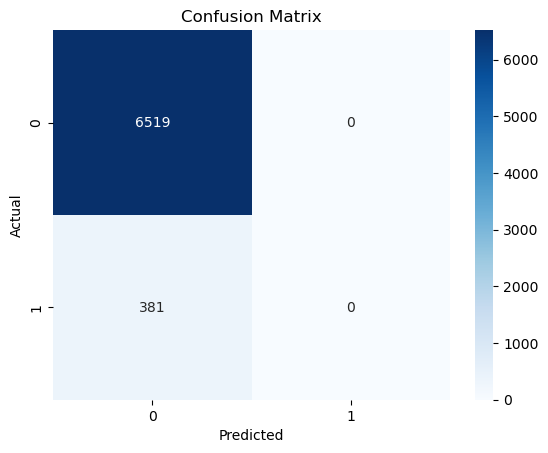

In [479]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

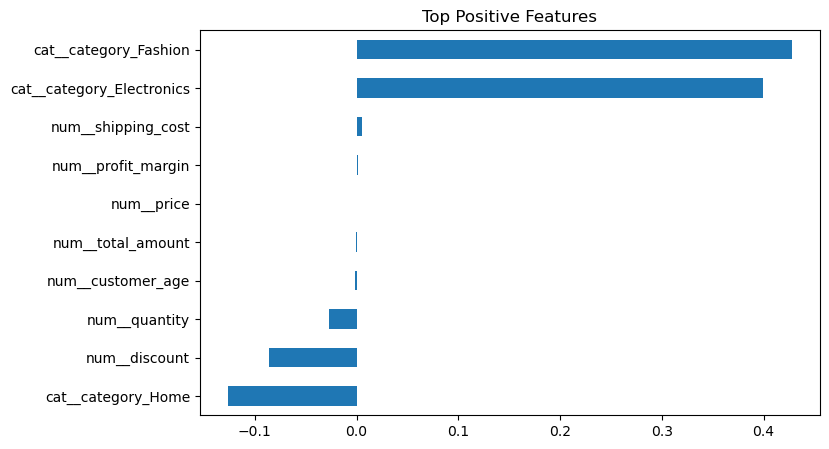

In [480]:
feature_names = preprocessor.get_feature_names_out()

coef = pd.Series(
    model.coef_[0],
    index=feature_names
)

coef.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Positive Features")
plt.show()

## Top Negative Features

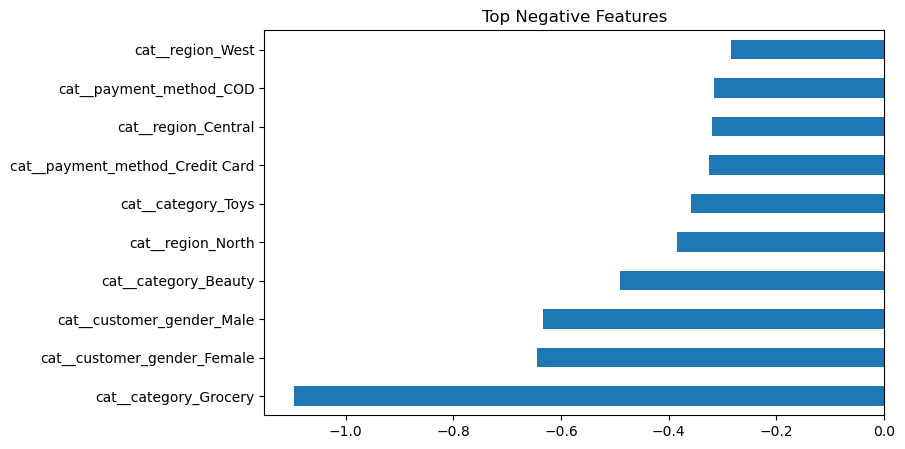

In [481]:
coef.sort_values().head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Negative Features")
plt.show()

In [482]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values("Coefficient", ascending=False).head(10)

,Feature,Coefficient
9,cat__category_Fashion,0.427527
8,cat__category_Electronics,0.399020
4,num__shipping_cost,0.005287
5,num__profit_margin,0.001679
0,num__price,-0.000049
3,num__total_amount,-0.000335
6,num__customer_age,-0.001889
2,num__quantity,-0.027552
1,num__discount,-0.086021
11,cat__category_Home,-0.126447


In [483]:
coef_df.sort_values("Coefficient").head(10)

,Feature,Coefficient
10,cat__category_Grocery,-1.096246
25,cat__customer_gender_Female,-0.644493
26,cat__customer_gender_Male,-0.633830
7,cat__category_Beauty,-0.489950
22,cat__region_North,-0.384589
13,cat__category_Toys,-0.358281
15,cat__payment_method_Credit Card,-0.324801
20,cat__region_Central,-0.319665
14,cat__payment_method_COD,-0.315418
24,cat__region_West,-0.285239


## Model Overview

In [484]:
print(model)
print(type(X_test), X_test.shape)
print(type(y_test), len(y_test))
print("y_pred defined:", 'y_pred' in globals())

LogisticRegression()
<class 'numpy.ndarray'> (6900, 28)
<class 'pandas.core.series.Series'> 6900
y_pred defined: True


## Model Save

In [485]:
joblib.dump(model, "return_prediction_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [489]:
df.drop(
    columns=["order_date", "delivered_date", "request_date"],
    errors="ignore",
    inplace=True
)

In [490]:
print(df.columns.tolist())

['category', 'price', 'discount', 'quantity', 'payment_method', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'delivery_days', 'return_request_days', 'order_month', 'order_year', 'order_day', 'weekend_order', 'high_discount', 'large_order', 'age_group', 'discount_bucket', 'profit_category', 'shipping_category']


In [491]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(27600, 28)
(6900, 28)
(27600,)
(6900,)
